# Task 2: Feature Engineering, Model Optimization & Performance Comparison

## House Price Prediction using Multiple Regression Models

### Objective

The objective of this project is to improve the performance of a house price prediction model by applying feature engineering techniques and comparing multiple regression algorithms.

The project covers data exploration, preprocessing, feature scaling, model training, prediction, evaluation, and performance comparison. Based on the evaluation metrics, the best-performing model is selected and saved for future use.

## Importing Required Libraries

This project uses Python libraries for data manipulation, visualization, machine learning, and model saving.

- NumPy is used for numerical computations.
- Pandas is used for handling tabular data.
- Matplotlib and Seaborn are used for data visualization.
- Scikit-learn provides datasets, preprocessing methods, regression algorithms, and evaluation metrics.
- Joblib is used to save the trained model.

In [45]:
 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib
sns.set(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## Loading the Dataset

The California Housing dataset is loaded from the Scikit-learn library.

It contains information about different housing districts in California. The dataset consists of various numerical features such as median income, house age, average number of rooms, population, and geographical location. The target variable represents the median house value.

In [46]:
 

housing = fetch_california_housing()
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)
df["HousePrice"] = housing.target
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [47]:
 

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Understanding the Dataset

Before building machine learning models, it is important to understand the structure of the dataset.

This includes checking the number of rows and columns, identifying the available features, and verifying the data types of each column.

In [48]:
 

print("Number of Rows and Columns:")
print(df.shape)

Number of Rows and Columns:
(20640, 9)


In [49]:
 

print("Dataset Columns:\n")
print(df.columns)

Dataset Columns:

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')


In [50]:
 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Statistical Summary

The statistical summary provides useful information about each numerical feature, including the mean, standard deviation, minimum value, maximum value, and quartiles.

This helps in understanding the overall distribution of the data.

In [51]:
 

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Checking for Missing Values

Missing values can negatively affect machine learning models.

This step checks whether the dataset contains any missing or null values.

In [52]:
 

df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

## Checking for Duplicate Records

Duplicate records may introduce bias into the model.

The following code checks whether duplicate rows are present in the dataset.

In [53]:
 

duplicates = df.duplicated().sum()
print("Number of Duplicate Records:", duplicates)

Number of Duplicate Records: 0


## Displaying Sample Records

Displaying random records from the dataset provides a quick overview of the data and helps verify that the dataset has been loaded correctly.

In [54]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
18805,2.1513,8.0,8.117845,1.558923,786.0,2.646465,40.61,-121.67,0.804
13680,3.2604,9.0,5.018106,1.094708,1782.0,2.481894,34.06,-117.24,0.933
17260,2.6983,49.0,4.586895,1.054131,961.0,2.737892,34.42,-119.72,2.601
7873,4.0507,30.0,4.816327,1.076067,1662.0,3.083488,33.88,-118.14,1.795
14613,2.2663,44.0,3.442922,0.984779,3009.0,4.579909,32.79,-117.17,1.236


## Data Visualization

Data visualization is an important step in data analysis.

It helps in understanding the distribution of features, identifying relationships between variables, and detecting patterns that may influence the machine learning models.

### Histogram

Histograms are used to visualize the distribution of numerical features in the dataset.

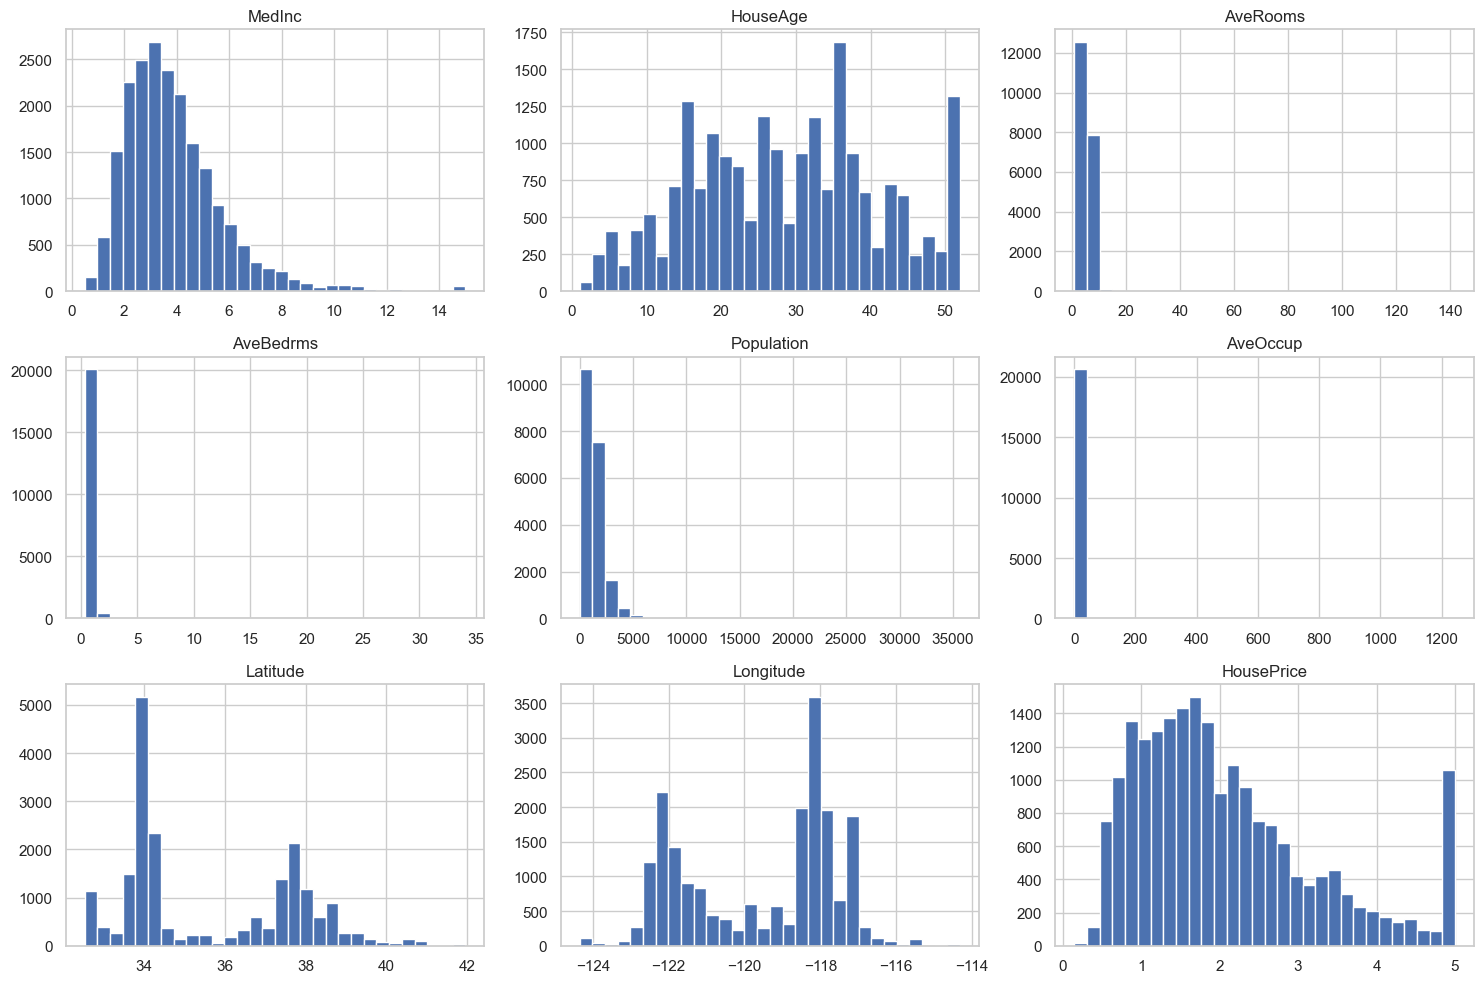

In [55]:
 

df.hist(
    figsize=(15,10),
    bins=30
)
plt.tight_layout()
plt.show()

### Correlation Heatmap

The correlation heatmap illustrates the relationship between different numerical features.

Correlation values closer to 1 or -1 indicate a stronger relationship between variables.

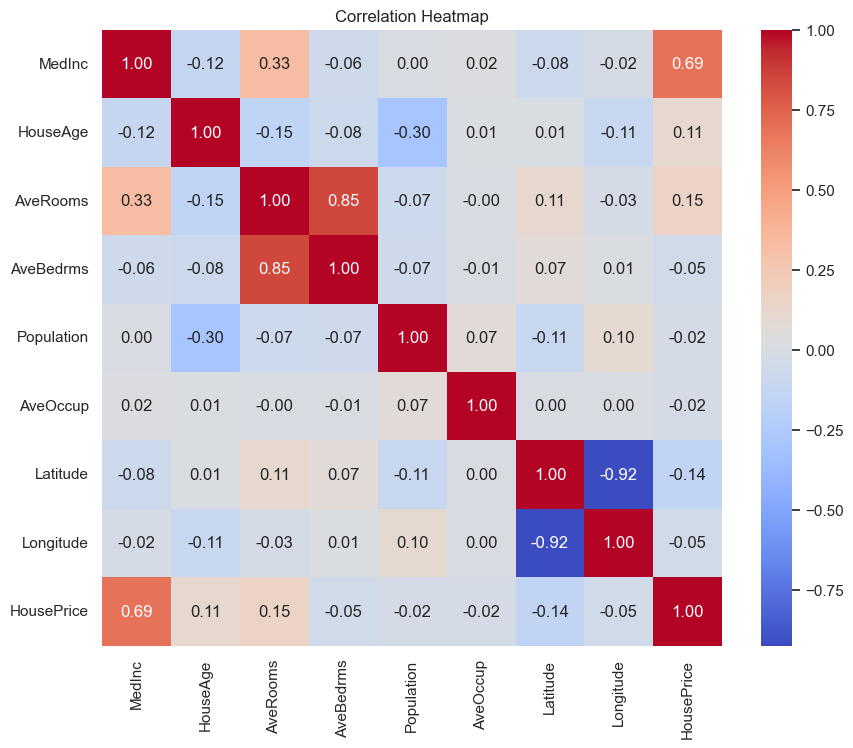

In [56]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

### Scatter Plot

The scatter plot shows the relationship between median income and house price.

This helps in understanding how income influences house prices.

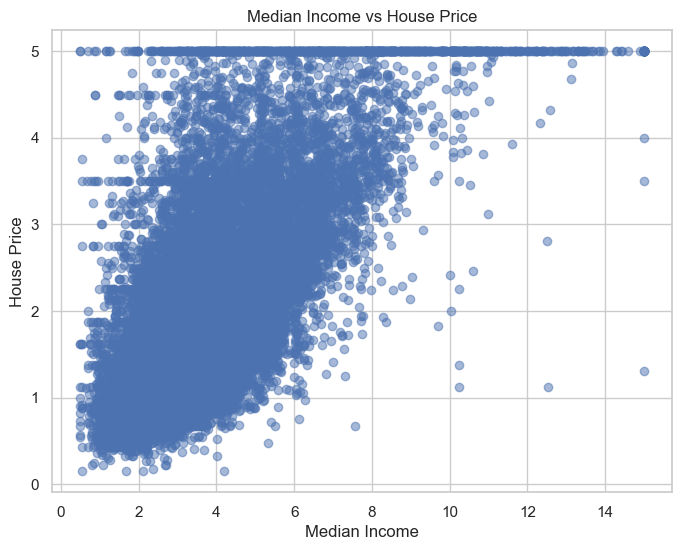

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["MedInc"],
    df["HousePrice"],
    alpha=0.5
)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")
plt.show()

### Box Plot

The box plot is used to identify the spread of the data and detect the presence of outliers in numerical features.

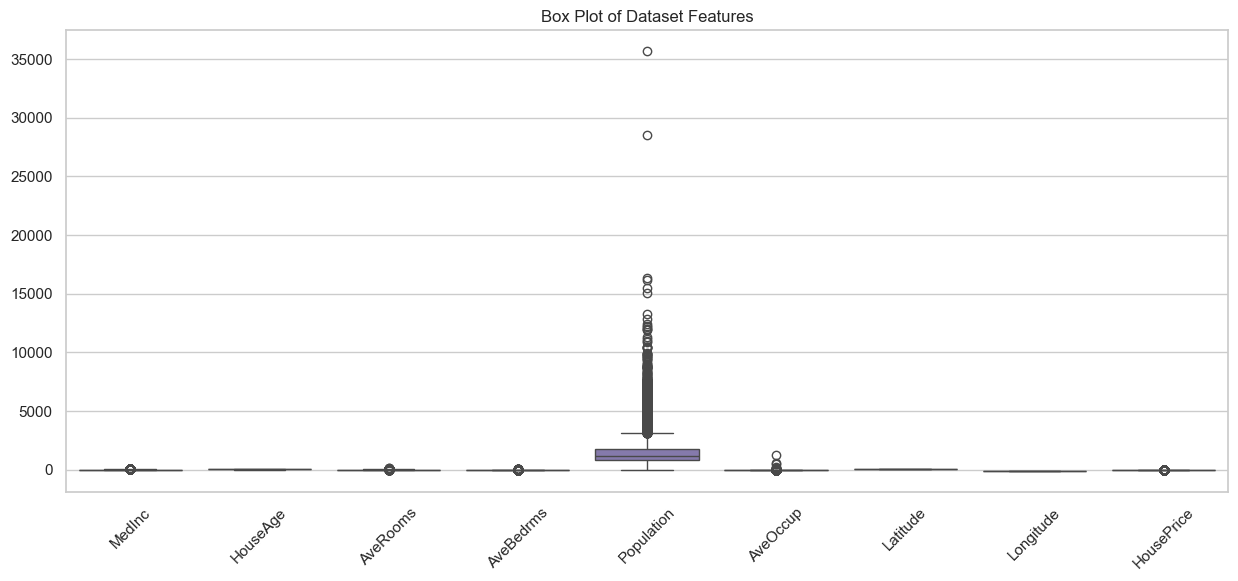

In [58]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot of Dataset Features")
plt.show()

## Feature Scaling

Feature scaling is a preprocessing technique used to standardize the range of independent variables.

In this project, the StandardScaler is used to transform the features so that they have a mean of 0 and a standard deviation of 1.

Scaling helps improve the performance of many machine learning algorithms by ensuring that all features contribute equally during model training.

In [59]:
 

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
print("Features and target variable separated successfully.")

Features and target variable separated successfully.


In [60]:
 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## Preparing the Dataset

The dataset is divided into input features and the target variable.

The scaled features will be used for training and testing the machine learning models.

In [61]:
 

print("Feature Matrix Shape :", X_scaled.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (20640, 8)
Target Shape : (20640,)


## Splitting the Dataset

The dataset is divided into training and testing sets.

Eighty percent of the data is used to train the models, while the remaining twenty percent is used to evaluate their performance.

In [62]:
 

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (16512, 8)
Testing Data Shape : (4128, 8)


## Model 1: Linear Regression

Linear Regression is one of the most commonly used supervised learning algorithms for predicting continuous numerical values.

It establishes a linear relationship between the input features and the target variable.

In [63]:
 

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Model 2: Ridge Regression

Ridge Regression is an extension of Linear Regression that includes regularization.

It helps reduce overfitting by applying a penalty to large coefficient values, resulting in a more stable model.

In [64]:
 

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


## Model 3: Decision Tree Regressor

Decision Tree Regression predicts numerical values by splitting the dataset into smaller decision nodes.

It can capture non-linear relationships and is useful for modeling complex patterns in the data.

In [65]:
 

tree_model = DecisionTreeRegressor(
    random_state=42
)
tree_model.fit(
    X_train,
    y_train
)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Making Predictions

After training the models, predictions are generated using the testing dataset.

These predicted values are compared with the actual values to evaluate the performance of each model.

In [66]:
 

linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


## Sample Predictions

The table below compares a few actual house prices with the predictions generated by the three regression models.

In [67]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Prediction": linear_pred,
    "Ridge Prediction": ridge_pred,
    "Decision Tree Prediction": tree_pred
})
comparison.head(10)

,Actual Price,Linear Prediction,Ridge Prediction,Decision Tree Prediction
0,0.47700,0.719123,0.719473,0.41400
1,0.45800,1.764017,1.763846,1.20300
2,5.00001,2.709659,2.709284,5.00001
3,2.18600,2.838926,2.838762,2.17000
4,2.78000,2.604657,2.604190,2.25700
5,1.58700,2.011754,2.011904,1.66400
6,1.98200,2.645500,2.645540,2.21700
7,1.57500,2.168755,2.168762,1.74000
8,3.40000,2.740746,2.740106,2.77200
9,4.46600,3.915615,3.915745,5.00001


## Model Evaluation

After training the machine learning models, their performance is evaluated using standard regression metrics.

The following metrics are used:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** Measures the average prediction error while giving more importance to larger errors.
- **R² Score:** Indicates how well the model explains the variance in the target variable. A higher R² score indicates better model performance.

In [68]:
 

def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    print("="*50)
    print(model_name)
    print("="*50)
    print("Mean Absolute Error :", round(mae,4))
    print("Root Mean Squared Error :", round(rmse,4))
    print("R² Score :", round(r2,4))
    print()
    return [model_name, mae, rmse, r2]

In [69]:
 

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)
ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred
)
tree_result = evaluate_model(
    "Decision Tree Regression",
    y_test,
    tree_pred
)

Linear Regression
Mean Absolute Error : 0.5332
Root Mean Squared Error : 0.7456
R² Score : 0.5758

Ridge Regression
Mean Absolute Error : 0.5332
Root Mean Squared Error : 0.7456
R² Score : 0.5758

Decision Tree Regression
Mean Absolute Error : 0.4531
Root Mean Squared Error : 0.7022
R² Score : 0.6237



## Performance Comparison

The evaluation metrics of all regression models are compared to identify the best-performing model.

The model with the lowest RMSE and highest R² Score is considered the best model.

In [70]:
 
results = pd.DataFrame(
    [linear_result,
     ridge_result,
     tree_result],

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score"
    ]
)
results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Ridge Regression,0.533193,0.745554,0.575819
2,Decision Tree Regression,0.453147,0.702173,0.623746


In [71]:
 

best_model_row = results.sort_values(
    by="R² Score",
    ascending=False
).iloc[0]
print("Best Model")
print(best_model_row)

Best Model
Model       Decision Tree Regression
MAE                         0.453147
RMSE                        0.702173
R² Score                    0.623746
Name: 2, dtype: object


## Saving the Best Model

The best-performing regression model is saved using Joblib.

This allows the trained model to be reused later without retraining.

In [72]:
 

model_dict = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Decision Tree Regression": tree_model
}
best_model = model_dict[
    best_model_row["Model"]
]
joblib.dump(
    best_model,
    "best_model.pkl"
)
print("Best model saved successfully.")

Best model saved successfully.


## Actual vs Predicted Values

The following scatter plot compares the actual house prices with the predicted house prices generated by the best-performing model.

A model with better performance will have prediction points closer to the diagonal trend.

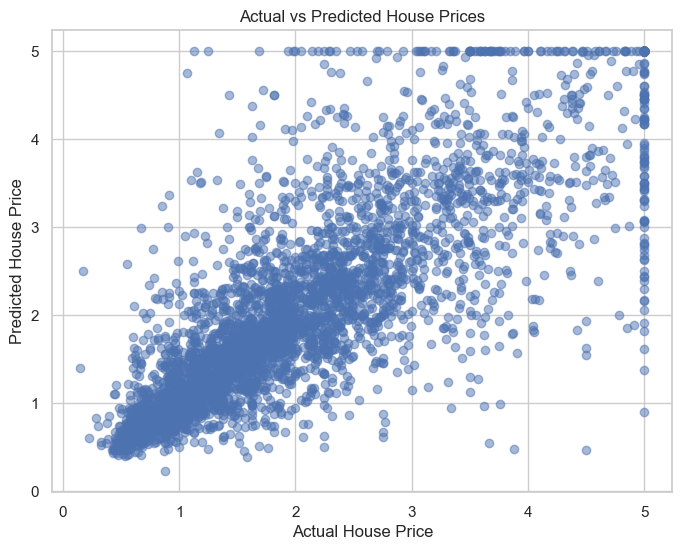

In [73]:
 

best_prediction = best_model.predict(X_test)
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    best_prediction,
    alpha=0.5
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

## Feature Importance

For tree-based models, feature importance indicates which input features have the greatest influence on predicting house prices.

This provides additional insight into the dataset and helps understand the contribution of each feature.

      Feature  Importance
0      MedInc    0.528330
5    AveOccup    0.131160
6    Latitude    0.092413
7   Longitude    0.084109
2    AveRooms    0.052970
1    HouseAge    0.051690
4  Population    0.030547
3   AveBedrms    0.028782


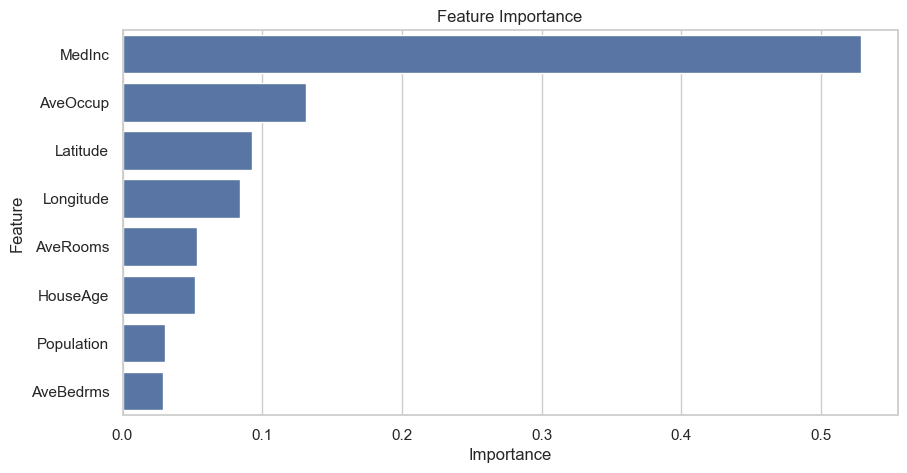

In [74]:
 
if best_model_row["Model"] == "Decision Tree Regression":
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": tree_model.feature_importances_
    })
    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )
    print(importance)
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )
    plt.title("Feature Importance")
    plt.show()

# Conclusion

In this project, feature engineering techniques were applied to improve the performance of house price prediction models.

The California Housing dataset was explored, visualized, and preprocessed using feature scaling. Three regression algorithms—Linear Regression, Ridge Regression, and Decision Tree Regression—were trained and evaluated using MAE, RMSE, and R² Score.

The performance comparison helped identify the most suitable model for this dataset. The best-performing model was saved for future use using Joblib.

This project provided practical experience in data preprocessing, model comparison, performance evaluation, and machine learning workflow implementation.